**The Broadcasting and Einsum Warm-up**
- **Task:** Using PyTorch (torch) or NumPy, create a 3D tensor representing a batch of images (batch_size=32, channels=3, height=64, width=64).
- 1. Multiply this tensor by a 1D tensor of channel weights (3,) using broadcasting.
- 2. Use torch.einsum (or np.einsum) to calculate the trace of a batch of 10 x 10 matrices.
- **Why:** Broadcasting is the source of 90% of shape bugs in deep learning. einsum is an incredibly powerful tool for writing clean, advanced matrix multiplications.

In [2]:
import torch

# Create a 4D tensor representing a batch of images: (batch_size, channels, height, width)
# Note: The prompt mentions a 3D tensor, but a batch of images natively requires 4 dimensions.
batch_size, channels, height, width = 32, 3, 64, 64
images = torch.rand(batch_size, channels, height, width)

# Create a 1D tensor of channel weights
weights = torch.tensor([0.2989, 0.5870, 0.1140])  # Example: Grayscale conversion weights

# Reshape weights to (channels, 1, 1) to enable broadcasting across batch, height, and width
weights_aligned = weights.view(channels, 1, 1)

# Multiply using broadcasting
weighted_images = images * weights_aligned

print("Images shape:", images.shape)
print("Weights aligned shape:", weights_aligned.shape)
print("Resulting tensor shape:", weighted_images.shape)

Images shape: torch.Size([32, 3, 64, 64])
Weights aligned shape: torch.Size([3, 1, 1])
Resulting tensor shape: torch.Size([32, 3, 64, 64])


In [3]:
# Create a batch of 10 matrices, each of size 10x10
batch_matrices = torch.rand(10, 10, 10)

# Calculate the trace for each matrix in the batch using einsum
# 'b' represents the batch dimension, 'i' and 'i' represent matching row/col subscripts for the diagonal
batch_traces = torch.einsum('bii->b', batch_matrices)

print("Batch matrices shape:", batch_matrices.shape)
print("Traces shape:", batch_traces.shape)
print("Calculated traces:\n", batch_traces)

Batch matrices shape: torch.Size([10, 10, 10])
Traces shape: torch.Size([10])
Calculated traces:
 tensor([5.2320, 6.1638, 5.8238, 3.5188, 5.0923, 4.7880, 4.4518, 5.7762, 4.5256,
        5.6191])


**Custom Tensor Operations**
- **Task:** Implement Batched Matrix Multiplication (BMM) from scratch using only standard 2D matrix multiplication loops, then compare its execution time against the built-in torch.bmm. Plot the performance difference as the batch size increases using Matplotlib.
- **Why:** Understands the computational efficiency of vectorized hardware-optimized operations versus naive implementations.

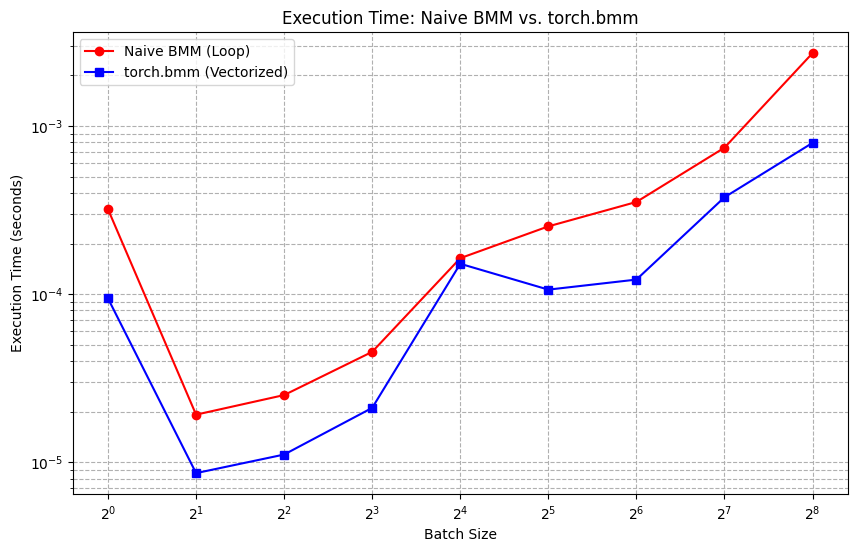

In [4]:
import time
import torch
import matplotlib.pyplot as plt

def naive_bmm(A, B):
    """
    Batched Matrix Multiplication from scratch using loops.
    A shape: (B, N, M)
    B shape: (B, M, P)
    Output shape: (B, N, P)
    """
    batch_size, N, M = A.shape
    _, _, P = B.shape
    
    # Initialize output tensor with zeros
    output = torch.zeros(batch_size, N, P)
    
    # Loop through each batch and perform standard 2D matrix multiplication
    for b in range(batch_size):
        output[b] = torch.mm(A[b], B[b])
        
    return output

# --- Performance Benchmark ---

batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256]
matrix_size = 64  # Fixed N, M, P dimensions for comparison

naive_times = []
torch_times = []

for b_size in batch_sizes:
    # Generate random tensors for the current batch size
    A = torch.rand(b_size, matrix_size, matrix_size)
    B = torch.rand(b_size, matrix_size, matrix_size)
    
    # Benchmark Naive BMM
    start_time = time.perf_counter()
    res_naive = naive_bmm(A, B)
    naive_times.append(time.perf_counter() - start_time)
    
    # Benchmark Built-in torch.bmm
    start_time = time.perf_counter()
    res_torch = torch.bmm(A, B)
    torch_times.append(time.perf_counter() - start_time)
    
    # Sanity check to ensure implementations match numerically
    assert torch.allclose(res_naive, res_torch, atol=1e-5), "Results do not match!"

# --- Plotting the Results ---

plt.figure(figsize=(10, 6))
plt.plot(batch_sizes, naive_times, marker='o', color='red', label='Naive BMM (Loop)')
plt.plot(batch_sizes, torch_times, marker='s', color='blue', label='torch.bmm (Vectorized)')

plt.title('Execution Time: Naive BMM vs. torch.bmm')
plt.xlabel('Batch Size')
plt.ylabel('Execution Time (seconds)')
plt.xscale('log', base=2)  # Log scale for clear visualization of doubling batch sizes
plt.yscale('log')          # Log scale to account for the massive performance gap
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()